In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder,
)

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import joblib

### Dataset

In [2]:
bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
y = bank_marketing.data.targets.squeeze()

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

X.head()

Dimensión de X: (45211, 16)
Dimensión de y: (45211,)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


In [5]:
df = X.copy()
df["target"] = y

df.head()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   contact      32191 non-null  str  
 9   day_of_week  45211 non-null  int64
 10  month        45211 non-null  str  
 11  duration     45211 non-null  int64
 12  campaign     45211 non-null  int64
 13  pdays        45211 non-null  int64
 14  previous     45211 non-null  int64
 15  poutcome     8252 non-null   str  
 16  target       45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [6]:
df["target"].value_counts()

target
no     39922
yes     5289
Name: count, dtype: int64

In [7]:
df["target"].value_counts(normalize=True)


target
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

### Preparar variables

In [8]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']

Variables categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


C:\Users\ALEX\AppData\Local\Temp\ipykernel_13080\3148038352.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [9]:
target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

print("Clases:")
print(target_encoder.classes_)

print(y_encoded[:10])


Clases:
['no' 'yes']
[0 0 0 0 0 0 0 0 0 0]


### Procesador


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [3]:
digits = fetch_ucirepo(id=80)

X = digits.data.features
y = digits.data.targets.squeeze()

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

X.head()

Dimensión de X: (5620, 64)
Dimensión de y: (5620,)


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60,Attribute61,Attribute62,Attribute63,Attribute64
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,0,6,14,7,1,0,0
1,0,0,10,16,6,0,0,0,0,7,...,3,0,0,0,10,16,15,3,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,0,9,14,0,0,0,0
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,0,1,15,2,0,0
4,0,0,5,14,4,0,0,0,0,0,...,12,0,0,0,4,12,14,7,0,0


In [4]:
print("Clases disponibles:", sorted(y.unique()))
print("\nDistribución de clases:")
print(y.value_counts().sort_index())

Clases disponibles: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Distribución de clases:
class
0    554
1    571
2    557
3    572
4    568
5    558
6    558
7    566
8    554
9    562
Name: count, dtype: int64


In [5]:
X_images = X.to_numpy().reshape(-1, 8, 8, 1)
y_values = y.to_numpy().astype("int")

print("Nueva forma de X:", X_images.shape)
print("Forma de y:", y_values.shape)

Nueva forma de X: (5620, 8, 8, 1)
Forma de y: (5620,)


###  Visualizar ejemplos

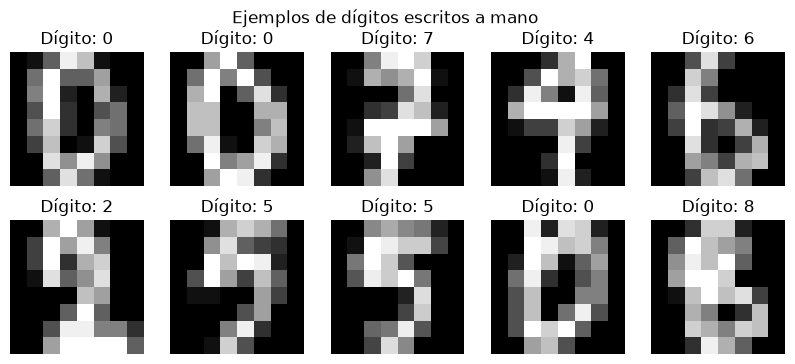

In [6]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_images[i].reshape(8,8), cmap="gray")
    plt.title(f"Dígito: {y_values[i]}")
    plt.axis("off")

plt.suptitle("Ejemplos de dígitos escritos a mano")
plt.show()

In [7]:
X_images = X_images / 16.0

print("Valor mínimo:", X_images.min())
print("Valor máximo:", X_images.max())

Valor mínimo: 0.0
Valor máximo: 1.0


In [8]:
num_classes = 10
y_categorical = to_categorical(y_values, num_classes=num_classes)

print("Ejemplo etiqueta original:", y_values[0])
print("Ejemplo etiqueta one-hot:", y_categorical[0])

Ejemplo etiqueta original: 0
Ejemplo etiqueta one-hot: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [9]:
X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X_images,
    y_categorical,
    y_values,
    test_size=0.30,
    random_state=42,
    stratify=y_values,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3934, 8, 8, 1)
X_test: (1686, 8, 8, 1)
y_train: (3934, 10)
y_test: (1686, 10)


In [10]:
model = Sequential([
    Conv2D(16, (3,3), activation="relu", input_shape=(8,8,1)),
    MaxPooling2D((2,2)),
    Conv2D(32,(2,2), activation="relu"),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\ALEX\Documents\SISTEMAS INTELIGENTES\sesion13\LABORATORIOS-COMPLEMENTARIOS\Manuscrito-a-texto-con-CNN-lab13\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 6, 6, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,146 (43.54 KB)

 Trainable params: 11,146 (43.54 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.4798 - loss: 1.8173 - val_accuracy: 0.7471 - val_loss: 0.9963
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8195 - loss: 0.6433 - val_accuracy: 0.9009 - val_loss: 0.3700
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8904 - loss: 0.3825 - val_accuracy: 0.9339 - val_loss: 0.2391
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9164 - loss: 0.2827 - val_accuracy: 0.9504 - val_loss: 0.1783
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9295 - loss: 0.2335 - val_accuracy: 0.9581 - val_loss: 0.1473
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9374 - loss: 0.2097 - val_accuracy: 0.9657 - val_loss: 0.1280
Epoch 7/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9476 - loss: 0.1835 - val_accuracy: 0.9670 - val_loss: 0.1178
Epoch 8/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9558 - loss: 0.1612 - val_accuracy: 0.9670 - v

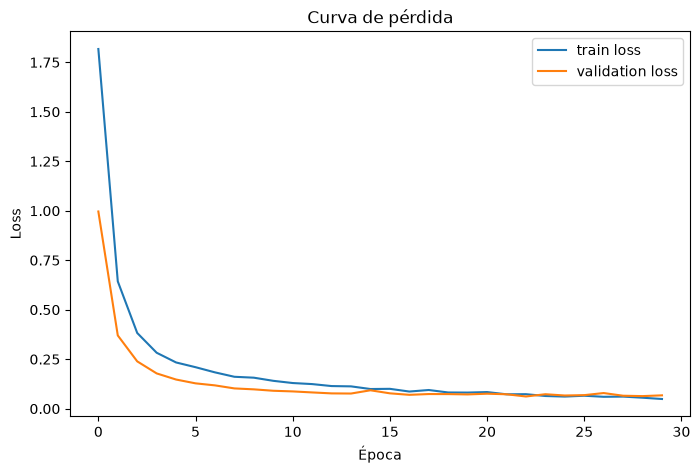

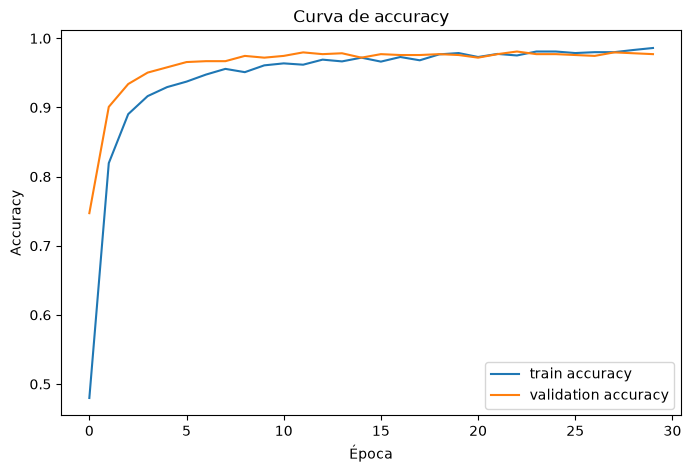

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curva de pérdida')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Curva de accuracy')
plt.legend()
plt.show()

In [13]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss    : 0.0528
Test accuracy: 0.9852


In [14]:
y_pred_prob = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test_labels, y_pred_labels))

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       166
           1       0.99      0.99      0.99       171
           2       0.99      0.99      0.99       167
           3       0.98      0.98      0.98       172
           4       0.98      0.99      0.99       171
           5       0.99      0.98      0.98       167
           6       0.99      0.99      0.99       167
           7       0.99      0.98      0.99       170
           8       0.98      0.98      0.98       166
           9       0.96      0.98      0.97       169

    accuracy                           0.99      1686
   macro avg       0.99      0.99      0.99      1686
weighted avg       0.99      0.99      0.99      1686



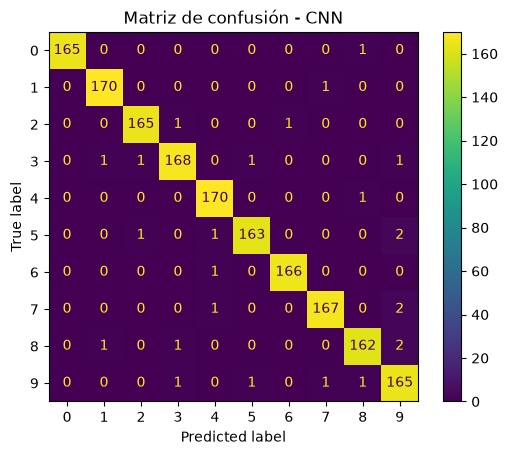

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test_labels,
    y_pred_labels,
    display_labels=list(range(10)),
)

plt.title("Matriz de confusión - CNN")
plt.show()

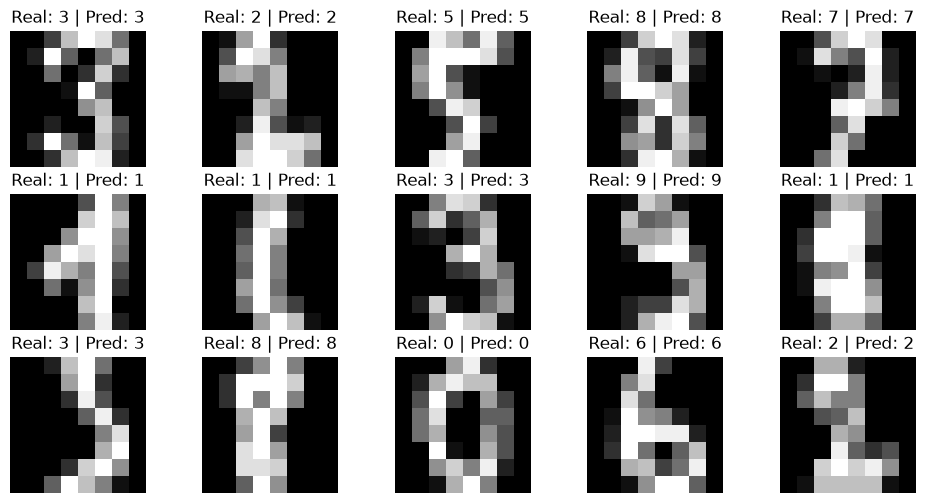

In [16]:
plt.figure(figsize=(12,6))

for i in range(15):
    plt.subplot(3,5,i+1)
    plt.imshow(X_test[i].reshape(8,8), cmap="gray")
    plt.title(f"Real: {y_test_labels[i]} | Pred: {y_pred_labels[i]}")
    plt.axis("off")

plt.show()

Cantidad de errores: 25


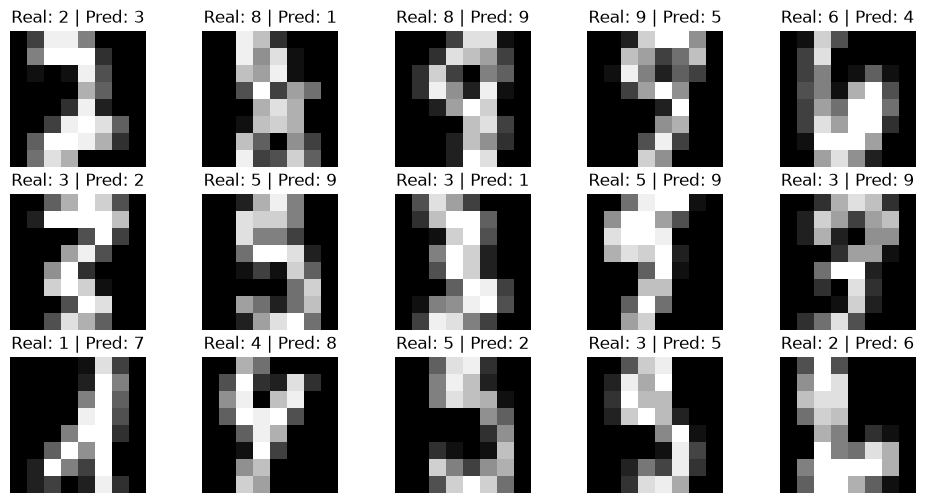

In [17]:
wrong_indices = np.where(y_test_labels != y_pred_labels)[0]

print("Cantidad de errores:", len(wrong_indices))

plt.figure(figsize=(12,6))

for plot_index, data_index in enumerate(wrong_indices[:15]):
    plt.subplot(3,5,plot_index+1)
    plt.imshow(X_test[data_index].reshape(8,8), cmap="gray")
    plt.title(f"Real: {y_test_labels[data_index]} | Pred: {y_pred_labels[data_index]}")
    plt.axis("off")

plt.show()

In [18]:
dense_model = Sequential([
    Flatten(input_shape=(8,8,1)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

dense_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dense_history = dense_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

dense_loss, dense_accuracy = dense_model.evaluate(X_test, y_test, verbose=0)

print(f'Accuracy CNN        : {test_accuracy:.4f}')
print(f'Accuracy Dense Model: {dense_accuracy:.4f}')

c:\Users\ALEX\Documents\SISTEMAS INTELIGENTES\sesion13\LABORATORIOS-COMPLEMENTARIOS\Manuscrito-a-texto-con-CNN-lab13\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Accuracy CNN        : 0.9852
Accuracy Dense Model: 0.9792


In [19]:
model.save("cnn_digits_uci.keras")
print("Modelo guardado como cnn_digits_uci.keras")

Modelo guardado como cnn_digits_uci.keras
